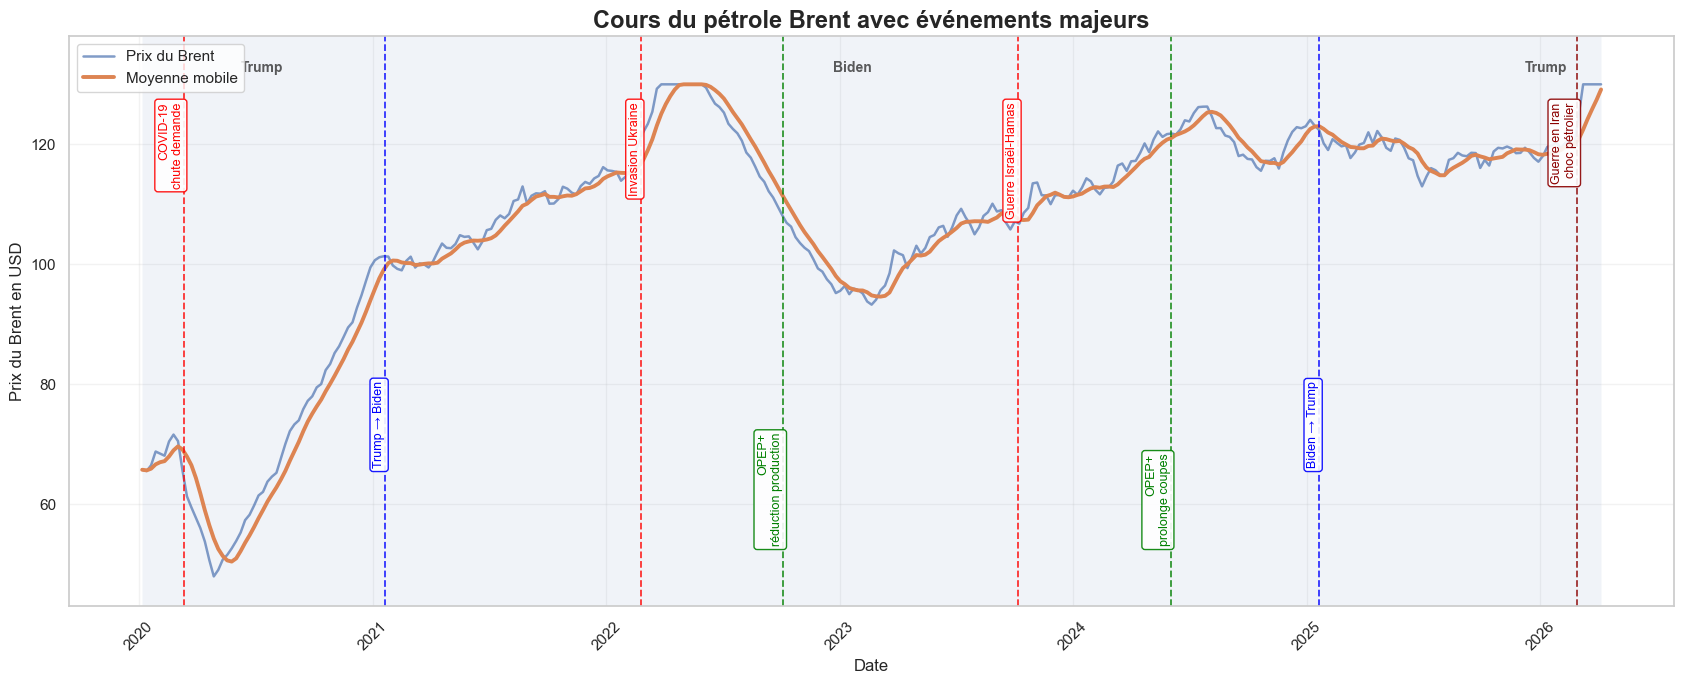

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# =========================
# 1. Charger les données
# =========================

df = pd.read_csv("global_fuel_prices_2020_2026.csv")

# Conversion de la colonne date
df["date"] = pd.to_datetime(df["date"])

# =========================
# 2. Filtrer les États-Unis
# =========================

us = df[df["country"] == "United States"].copy()
us = us.sort_values("date")

# Moyenne du Brent par date
oil = us.groupby("date", as_index=False)["brent_crude_usd"].mean()

# Moyenne mobile pour lisser la courbe
oil["rolling_mean"] = oil["brent_crude_usd"].rolling(
    window=6,
    min_periods=1
).mean()

# Bornes du dataset
data_start = oil["date"].min()
data_end = oil["date"].max()

# Valeurs min/max pour placer les annotations
y_min = oil["brent_crude_usd"].min()
y_max = oil["brent_crude_usd"].max()

# =========================
# 3. Créer le graphique
# =========================

fig, ax = plt.subplots(figsize=(17, 7))

# Courbe principale du Brent
ax.plot(
    oil["date"],
    oil["brent_crude_usd"],
    linewidth=1.8,
    alpha=0.7,
    label="Prix du Brent"
)

# Moyenne mobile
ax.plot(
    oil["date"],
    oil["rolling_mean"],
    linewidth=2.8,
    label="Moyenne mobile"
)

# =========================
# 4. Zones présidentielles
# =========================

presidencies = [
    ("2020-01-01", "2021-01-20", "Trump"),
    ("2021-01-20", "2025-01-20", "Biden"),
    ("2025-01-20", "2026-12-31", "Trump"),
]

for start, end, president in presidencies:
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)

    if end_date >= data_start and start_date <= data_end:
        ax.axvspan(
            max(start_date, data_start),
            min(end_date, data_end),
            alpha=0.08
        )

        mid_date = start_date + (end_date - start_date) / 2

        if data_start <= mid_date <= data_end:
            ax.text(
                mid_date,
                y_max + 1.5,
                president,
                ha="center",
                va="bottom",
                fontsize=10,
                weight="bold",
                alpha=0.75
            )

# =========================
# 5. Événements majeurs
# =========================

events = [
    ("2020-03-11", "COVID-19\nchute demande", "red"),
    ("2021-01-20", "Trump → Biden", "blue"),
    ("2022-02-24", "Invasion Ukraine", "red"),
    ("2022-10-05", "OPEP+\nréduction production", "green"),
    ("2023-10-07", "Guerre Israël-Hamas", "red"),
    ("2024-06-02", "OPEP+\nprolonge coupes", "green"),
    ("2025-01-20", "Biden → Trump", "blue"),
    ("2026-02-28", "Guerre en Iran\nchoc pétrolier", "darkred"),
]

for date_str, label, color in events:
    event_date = pd.Timestamp(date_str)

    if data_start <= event_date <= data_end:
        # Ligne verticale
        ax.axvline(
            event_date,
            color=color,
            linestyle="--",
            linewidth=1.3,
            alpha=0.8
        )

        # Position des labels
        if "OPEP" in label:
            y_pos = y_min + 5
            va = "bottom"
        elif "Trump" in label or "Biden" in label:
            y_pos = y_min + 18
            va = "bottom"
        else:
            y_pos = y_max - 3
            va = "top"

        # Annotation
        ax.text(
            event_date,
            y_pos,
            label,
            rotation=90,
            va=va,
            ha="right",
            fontsize=9,
            color=color,
            bbox=dict(
                facecolor="white",
                edgecolor=color,
                boxstyle="round,pad=0.25",
                alpha=0.9
            )
        )

# =========================
# 6. Mise en forme finale
# =========================

ax.set_title(
    "Cours du pétrole Brent avec événements majeurs",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Prix du Brent en USD")

ax.set_ylim(y_min - 5, y_max + 8)

ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

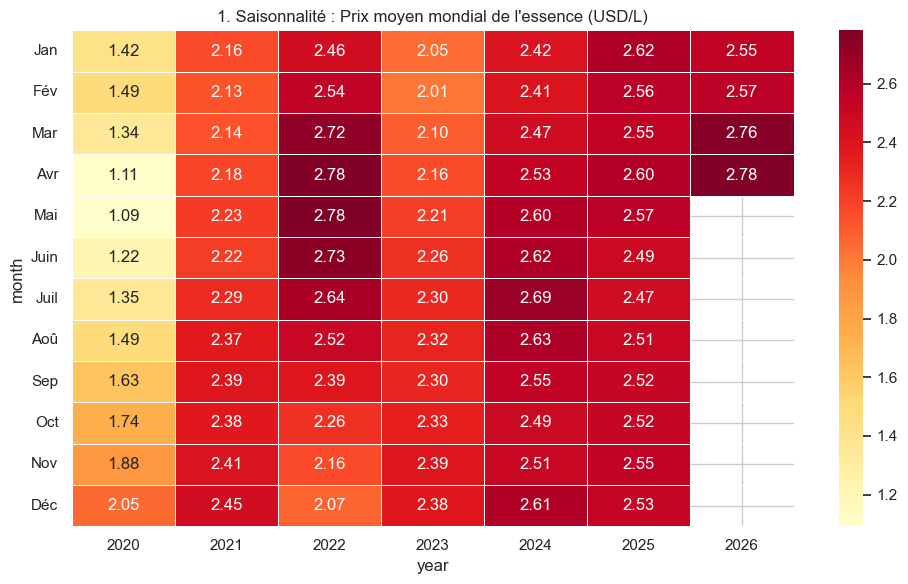

In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
monthly_avg = df.pivot_table(index='month', columns='year', values='petrol_usd_liter', aggfunc='mean')
sns.heatmap(monthly_avg, cmap='YlOrRd', annot=True, fmt=".2f", linewidths=.5)
plt.title('1. Saisonnalité : Prix moyen mondial de l\'essence (USD/L)')
plt.yticks(ticks=np.arange(0.5, 12.5, 1), labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'], rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

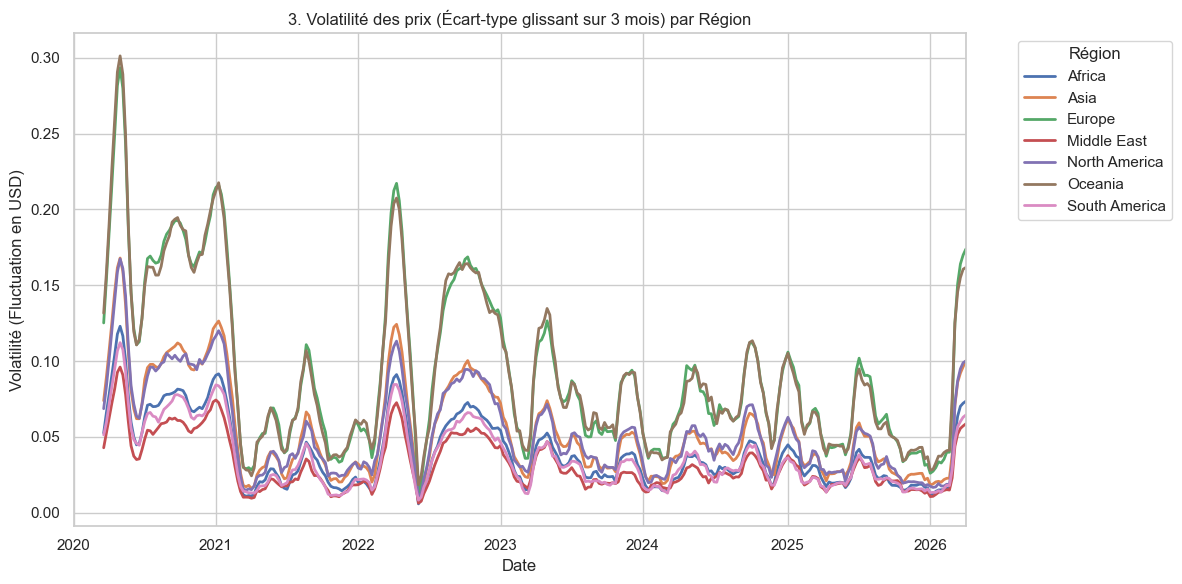

In [6]:
plt.figure(figsize=(12, 6))
region_daily = df.groupby(['date', 'region'])['petrol_usd_liter'].mean().unstack()
rolling_volatility = region_daily.rolling(window=12).std() # 12 semaines = ~3 mois
rolling_volatility.plot(figsize=(12,6), linewidth=2)
plt.title('3. Volatilité des prix (Écart-type glissant sur 3 mois) par Région')
plt.ylabel('Volatilité (Fluctuation en USD)')
plt.xlabel('Date')
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_8736\3186932883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_inflation.values, y=top_inflation.index, palette='rocket')


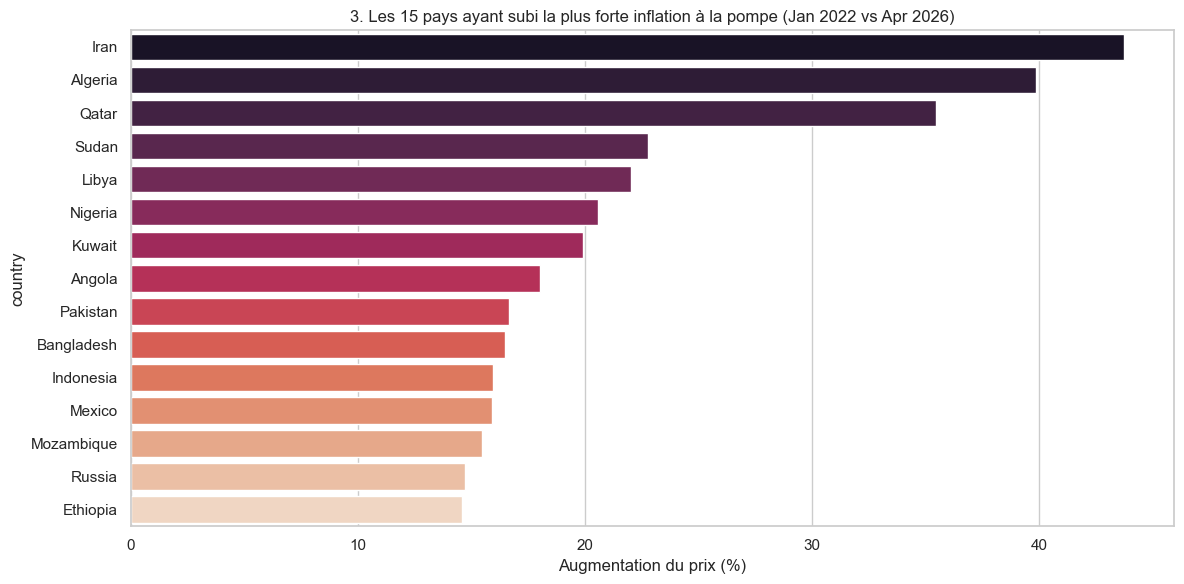

In [10]:
df_2022 = df[df['date'] == '2022-01-03'].groupby('country')['petrol_usd_liter'].mean()
recent_date = df['date'].max()
df_recent = df[df['date'] == recent_date].groupby('country')['petrol_usd_liter'].mean()
inflation = ((df_recent - df_2022) / df_2022 * 100).dropna().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
top_inflation = inflation.head(15)
sns.barplot(x=top_inflation.values, y=top_inflation.index, palette='rocket')
plt.title(f'3. Les 15 pays ayant subi la plus forte inflation à la pompe (Jan 2022 vs {recent_date.strftime("%b %Y")})')
plt.xlabel('Augmentation du prix (%)')
plt.tight_layout()
plt.show()